# PROJET 8 - REALISATION D'UNE VEILLE TECHNIQUE
***

## 1 - NETTOYAGE
***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import adjusted_rand_score

In [2]:
import nltk

#chemin de data nltk
nltk.data.path.append('/home/adrien/devcode/python/environnements/env_nlp/nltk_data/')

In [3]:
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import words
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

In [4]:
# on importe notre jeu de données
data = pd.read_csv('./data/data_nlp.csv')

In [5]:
data.head()

,Unnamed: 0,uniq_id,product_name,main_category,tokenized_description,cleaned_description,nb_tokens,nb_char
0,0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,Home Furnishing,"['abstract', 'eyelet', 'door', 'curtain', 'flo...",abstract eyelet door curtain floral curtain ab...,75,492
1,1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,Baby Care,"['bath', 'towel', 'bath', 'towel', 'red', 'yel...",bath towel bath towel red yellow blue bath tow...,22,119
2,2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,Baby Care,"['face', 'towel', 'small', 'height', 'face', '...",face towel small height face towel face towel ...,51,297
3,3,d4684dcdc759dd9cdf41504698d737d8,SANTOSH ROYAL FASHION Cotton Printed King size...,Home Furnishing,"['royal', 'fashion', 'king', 'royal', 'wedding...",royal fashion king royal wedding royal fashion...,44,277
4,4,6325b6870c54cd47be6ebfbffa620ec7,Jaipur Print Cotton Floral King sized Double B...,Home Furnishing,"['print', 'floral', 'king', 'print', 'floral',...",print floral king print floral king bed sheet ...,73,425


## 2 - USE
***

In [6]:
import tensorflow as tf
import tensorflow_hub as hub

2024-09-26 07:28:44.165775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-26 07:28:44.327349: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-26 07:28:44.391769: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-26 07:28:44.668541: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-26 07:28:46.184065: W tensorflow/compiler/tf2

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [8]:
# on instancie une pca et un tsne

pipeline_pca_tsne = Pipeline([
    ('pca', PCA(n_components = 0.99)),
    ('tsne', TSNE(n_components = 2,  init='random', random_state = 42))
])

In [9]:
kmeans = KMeans(n_clusters=data['main_category'].unique().shape[0], n_init = 'auto', init = 'k-means++', random_state = 42)
rfc = RandomForestClassifier(n_estimators = 200)
logreg = LogisticRegression(C=0.1, max_iter = 1000)

In [10]:
data_scores = pd.DataFrame({
    'modele': ['use', 'roberta', 't5', 'e5-base-v2', 'e5-large-v2'],
    'kmeans_ari': [None] * 5,
    'kmeans_acc': [None] * 5,
    'kmeans_f1': [None] * 5,
    'rfc_ari': [None] * 5,
    'rfc_acc': [None] * 5,
    'rfc_f1': [None] * 5,
    'logreg_ari': [None] * 5,
    'logreg_acc': [None] * 5,
    'logreg_f1': [None] * 5
})

In [11]:
# on met nos labels dans un autre dataframe

data_kmeans_labels = pd.DataFrame()
data_kmeans_labels['true_labels'] = data['main_category']

In [12]:
# on encode nos catégories

label_encoder = LabelEncoder()
data_kmeans_labels['true_labels_encoded'] = label_encoder.fit_transform(data_kmeans_labels['true_labels'])

In [55]:
def clustering_analysis(model_outputs, model_name, plot_title):

    """
    Effectue une analyse de clustering en utilisant PCA, t-SNE, K-Means et réalignement des labels,
    puis visualise les résultats sous forme de graphiques en 2D, et calcule le score ARI.

    Parameters
    ----------
    model_outputs : np.array
        Les sorties du modèle de type array ou dataframe qui seront utilisées comme entrée pour 
        la réduction de dimension et le clustering.
    
    column_name : str
        Le nom de la colonne dans laquelle les labels réassignés seront stockés dans le dataframe 
        `data_labels`.
    
    model_name : str
        Le nom du modèle à afficher dans le titre du graphique. Ce nom sera utilisé pour annoter le
        type de modèle utilisé pour générer les sorties (ex. 'Model A - PCA + TSNE').
    
    Returns
    -------
    None
        La fonction ne retourne rien, mais affiche un graphique comparant les labels réels et 
        les labels prédits par K-Means après réalignement. Elle ajoute également les labels réassignés
        dans le dataframe `data_labels` et affiche le score ARI sur le graphique.
    
    Processus
    ---------
    1. Réduction de dimension : Applique d'abord PCA et t-SNE sur les sorties du modèle (`model_outputs`)
       via une pipeline pour projeter les données dans un espace de faible dimension.
    
    2. Clustering : Utilise K-Means pour effectuer un clustering sur les données réduites.
    
    3. Réalignement : Utilise une méthode de "linear assignment" (optimisation combinatoire) pour 
       réaligner les labels K-Means avec les vrais labels (en maximisant la similarité entre les deux).
    
    4. Calcul de l'ARI : Calcule le score Adjusted Rand Index (ARI), qui mesure la similarité entre
       les clusters réassignés et les vrais labels.
    
    5. Visualisation : Crée deux graphiques en 2D : l'un montrant les vrais labels, l'autre les labels
       prédits après réalignement. Le score ARI est annoté sur le graphique des labels prédits.
    
    6. Légende : Ajoute une légende au bas du graphique pour indiquer les différentes catégories de labels.
    
    Notes
    -----
    - Les sorties du modèle sont réduites à 2 dimensions pour visualiser les résultats sous forme de 
      scatter plots.
    - Le réalignement des labels est effectué avec une matrice de confusion, suivie d'une optimisation 
      de l'affectation via l'algorithme `linear_sum_assignment`.
    - L'ARI score est un indicateur clé pour évaluer la qualité des clusters par rapport aux vrais labels.
    
    """
    
    # on fait passer les outputs du modèle dans la pipeline
    X = pipeline_pca_tsne.fit_transform(model_outputs)
    y = data_kmeans_labels['true_labels_encoded'].tolist()
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
    rfc.fit(X_train, y_train)
    logreg.fit(X_train, y_train)
    
    # on sort les labels kmeans
    kmeans_labels = kmeans.fit_predict(X)
    
    # on réaligne les labels
    conf_mat = confusion_matrix(y, kmeans_labels)
    row, col = linear_sum_assignment(-conf_mat)
    
    for i in range(len(kmeans_labels)):
        kmeans_labels[i] = np.where(col == kmeans_labels[i])[0][0]

    data_kmeans_labels[model_name + '_' + 'labels'] = kmeans_labels
    
    rfc_labels = rfc.predict(X_test)
    logreg_labels = logreg.predict(X_test)
    
    #on calcule les scores
    ari_score_kmeans = adjusted_rand_score(y, kmeans_labels)
    accuracy_kmeans = accuracy_score(y, kmeans_labels)
    f1_score_kmeans = f1_score(y, kmeans_labels, average='macro')
    kmeans_scores = [ari_score_kmeans, accuracy_kmeans, f1_score_kmeans]

    ari_score_rfc = adjusted_rand_score(y_test, rfc_labels)
    accuracy_rfc = accuracy_score(y_test, rfc_labels)
    f1_score_rfc = f1_score(y_test, rfc_labels, average='macro')
    rfc_scores = [ari_score_rfc, accuracy_rfc, f1_score_rfc]

    ari_score_logreg = adjusted_rand_score(y_test, logreg_labels)
    accuracy_logreg = accuracy_score(y_test, logreg_labels)
    f1_score_logreg = f1_score(y_test, logreg_labels, average='macro')
    logreg_scores = [ari_score_logreg, accuracy_logreg, f1_score_logreg]

    data_scores.loc[data_scores['modele'] == model_name, ['kmeans_ari', 'kmeans_acc', 'kmeans_f1']] = kmeans_scores
    data_scores.loc[data_scores['modele'] == model_name, ['rfc_ari', 'rfc_acc', 'rfc_f1']] = rfc_scores
    data_scores.loc[data_scores['modele'] == model_name, ['logreg_ari', 'logreg_acc', 'logreg_f1']] = logreg_scores
    
    # on plot
    plt.rc('text', usetex = True)
    plt.rc('font', family = 'serif', size = 16)
    
    palette_deep = sns.color_palette("deep", 7)
    palette_deep_mapping = {i: color for i, color in enumerate(palette_deep)}
    
    fig, axes = plt.subplots(1,2, figsize = (14,6), gridspec_kw={'width_ratios':[1,1]})
    sns.scatterplot(x = X[:,0], y = X[:,1], palette = palette_deep_mapping, legend = False, hue = y, ax = axes[0])
    sns.scatterplot(x = X[:,0], y = X[:,1], palette = palette_deep_mapping, legend = False, hue = kmeans_labels, ax = axes[1])
    axes[0].set_title("\\textbf{{Vrais labels}}", size = 14)
    axes[1].set_title("\\textbf{{KMeans labels}}", size = 14)
    
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
        
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    
    axes[1].text(0.97, 0.965, f"ARI : {round(ari_score_kmeans, 2)}", horizontalalignment='right', verticalalignment='top', transform=axes[1].transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.5))
    
    #légende
    category_names = label_encoder.inverse_transform(range(len(label_encoder.classes_)))
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette_deep_mapping[i], markersize=9, label=category_names[i]) for i in range(len(category_names))]
    plt.legend(handles=handles, title="\\textbf{{Catégories}}", loc='lower center', bbox_to_anchor=(-0.078, -0.35), ncol=3)
        
    plt.suptitle(f"\\textbf{{{plot_title} $-$ PCA + TSNE}}")
    #plt.savefig(f"./graphics/scatter_use_{name}.pdf", bbox_inches='tight')
    plt.show()

    return X_test, y_test, rfc_labels, logreg_labels

In [14]:
#On instancie notre modèle
model_use = hub.load("/home/adrien/devcode/python/data/use_model/")

#Les outputs 
use_outputs = np.array(model_use(data["cleaned_description"].tolist()))

I0000 00:00:1727328536.004968    4902 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-09-26 07:28:56.264521: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


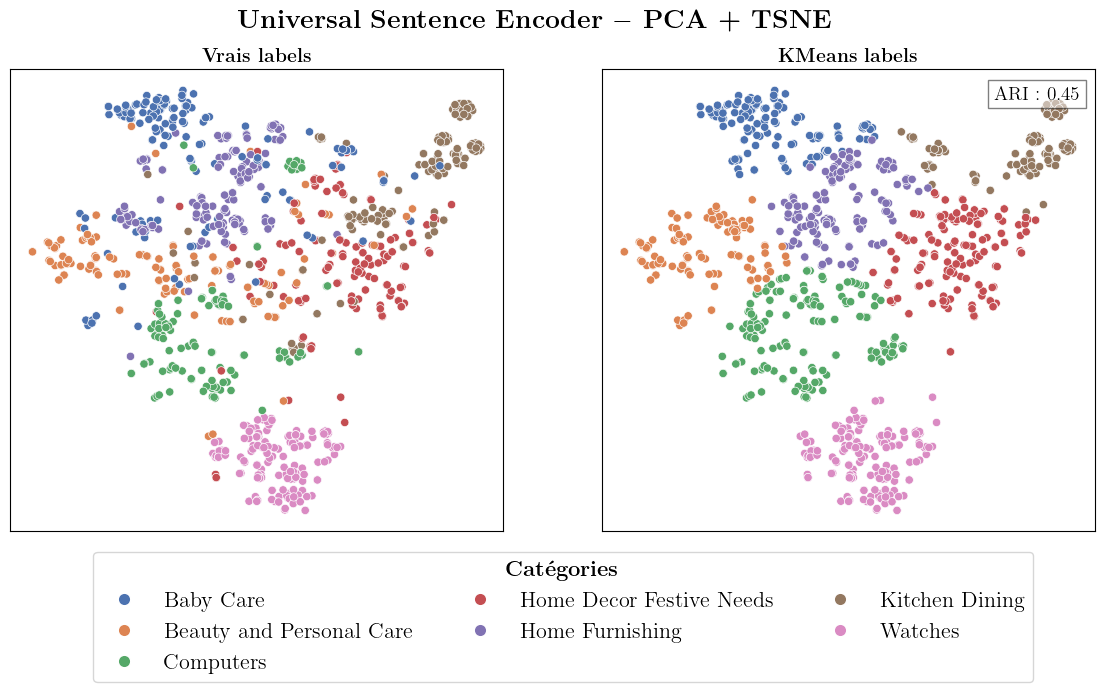

In [56]:
X_test_use, y_test, use_rfc_labels, use_logreg_labels = clustering_analysis(np.array(use_outputs), 'use', 'Universal Sentence Encoder')

## 3 - ROBERTA
***

In [20]:
import torch
from transformers import RobertaTokenizer, RobertaModel

/home/adrien/devcode/python/environnements/env_nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base', clean_up_tokenization_spaces=True)
roberta_model = RobertaModel.from_pretrained('roberta-base')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
roberta_inputs = roberta_tokenizer(data['cleaned_description'].tolist(), padding = True, truncation = True, return_tensors = 'pt')

In [23]:
with torch.no_grad():
    roberta_outputs = roberta_model(**roberta_inputs)

roberta_embeddings = roberta_outputs.last_hidden_state.mean(dim=1)
roberta_embeddings = np.array(roberta_embeddings)

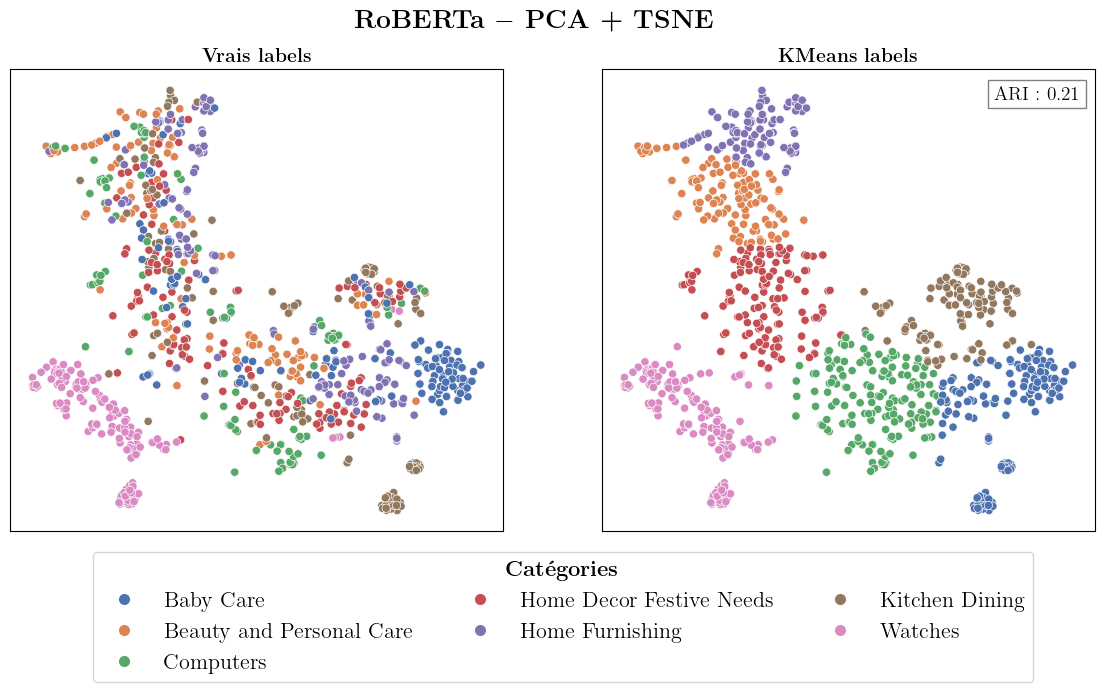

In [57]:
X_test_roberta, y_test, roberta_rfc_labels, roberta_logreg_labels = clustering_analysis(roberta_embeddings, 'roberta', 'RoBERTa')

## 4 - T5
***

In [25]:
from transformers import T5Tokenizer, T5EncoderModel

In [26]:
t5_tokenizer = T5Tokenizer.from_pretrained('t5-base')
t5_model = T5EncoderModel.from_pretrained('t5-base')

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/adrien/devcode/python/environnements/env_nlp/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [27]:
t5_inputs = t5_tokenizer(data['cleaned_description'].tolist(), padding = True, truncation = True, return_tensors = 'pt', max_length = 512)

In [28]:
with torch.no_grad():
    t5_outputs = t5_model(**t5_inputs)

t5_embeddings = np.array(t5_outputs.last_hidden_state.mean(dim=1))

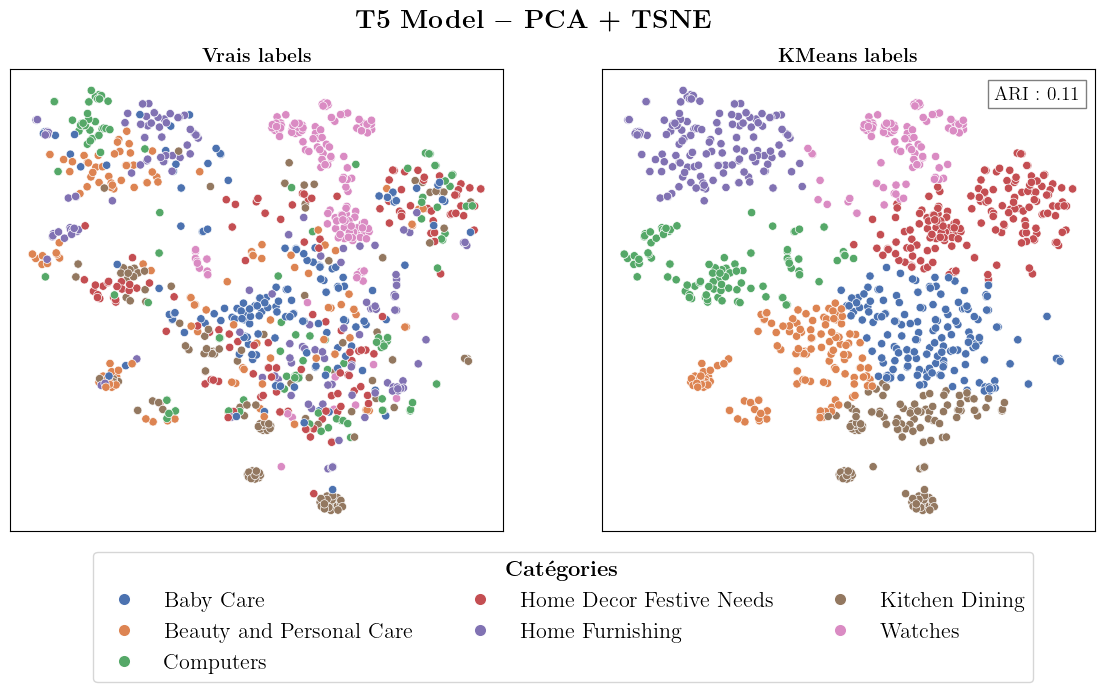

In [58]:
X_test_t5, y_test, t5_rfc_labels, t5_logreg_labels = clustering_analysis(t5_embeddings, 't5', 'T5 Model')

## 5 - E5
***

In [30]:
import torch
from transformers import AutoTokenizer, AutoModel

### 5.1 - E5 Base V2
***

In [31]:
e5_base_tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-base-v2")
e5_base_model = AutoModel.from_pretrained("intfloat/e5-base-v2")

e5_base_inputs = e5_base_tokenizer(data['cleaned_description'].tolist(), return_tensors = 'pt', padding = True, truncation = True)

In [32]:
with torch.no_grad():
    e5_base_outputs = e5_base_model(**e5_base_inputs).last_hidden_state[:, 0, :]

e5_base_embeddings = torch.nn.functional.normalize(e5_base_outputs, p = 2, dim = 1)
e5_base_embeddings = np.array(e5_base_embeddings)

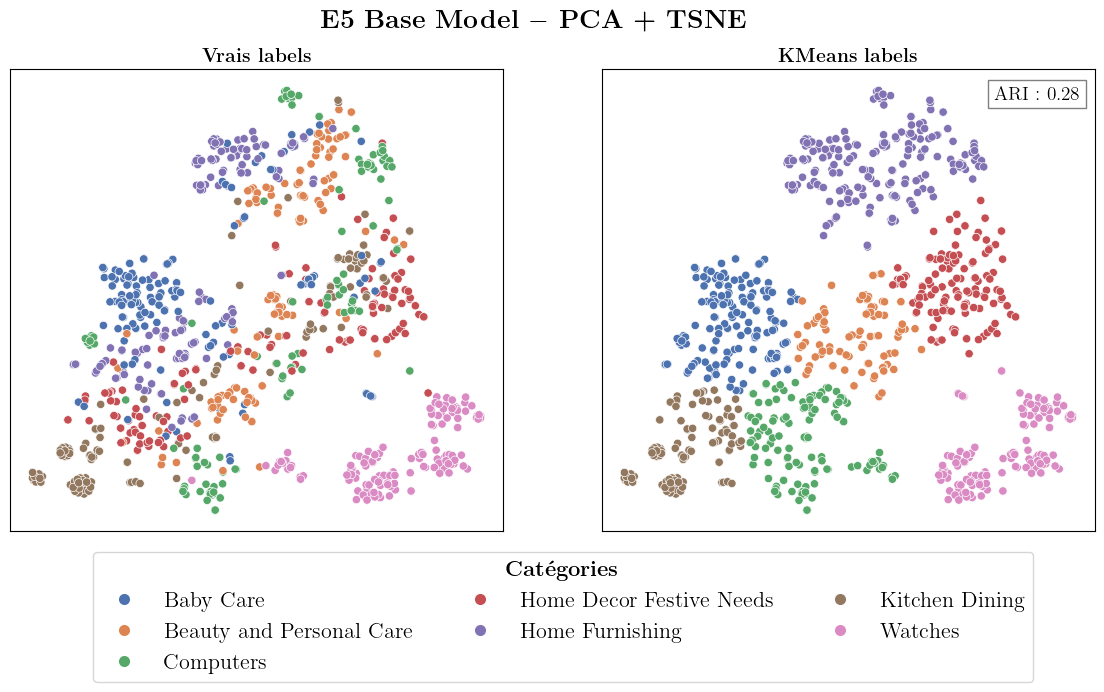

In [59]:
X_test_e5_base, y_test, e5_base_rfc_labels, e5_base_logreg_labels = clustering_analysis(e5_base_embeddings, 'e5-base-v2', 'E5 Base Model')

### 5.2 - E5 Large V2
***

In [35]:
e5_large_tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-large-v2")
e5_large_model = AutoModel.from_pretrained("intfloat/e5-large-v2")

e5_large_inputs = e5_large_tokenizer(data['cleaned_description'].tolist(), return_tensors = 'pt', padding = True, truncation = True)

In [36]:
with torch.no_grad():
    e5_large_outputs = e5_large_model(**e5_large_inputs).last_hidden_state[:, 0, :]

e5_large_embeddings = torch.nn.functional.normalize(e5_large_outputs, p = 2, dim = 1)
e5_large_embeddings = np.array(e5_large_embeddings)

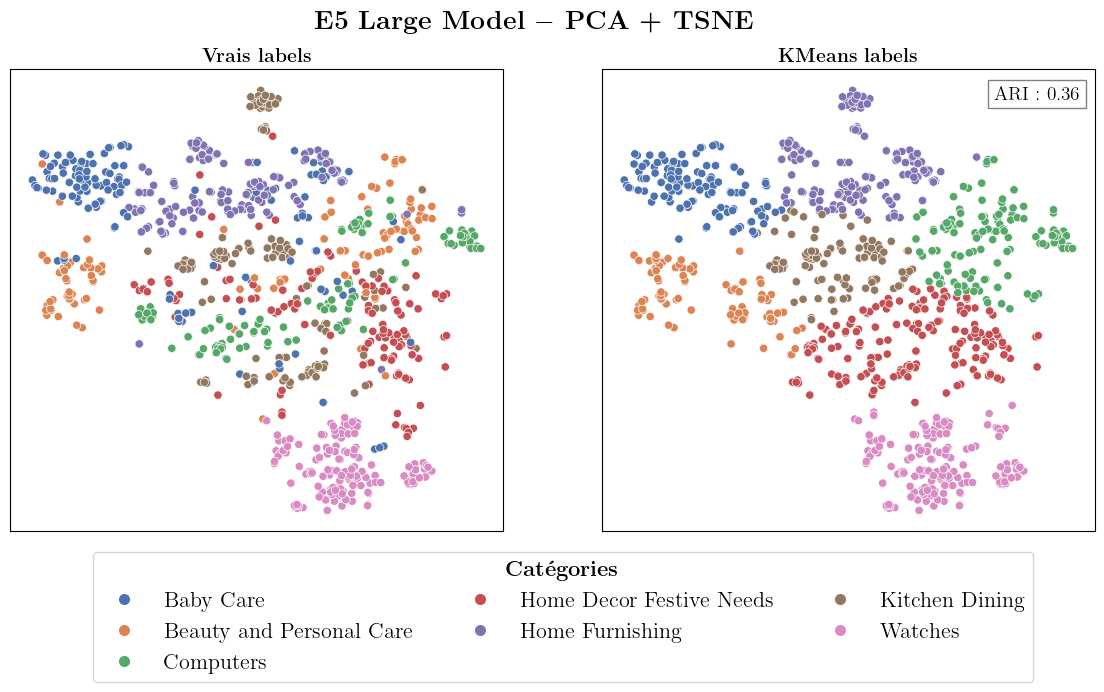

In [60]:
X_test_e5_large, y_test, e5_large_rfc_labels, e5_large_logreg_labels = clustering_analysis(e5_large_embeddings, 'e5-large-v2', 'E5 Large Model')

In [49]:
data_scores

,modele,kmeans_ari,kmeans_acc,kmeans_f1,rfc_ari,rfc_acc,rfc_f1,logreg_ari,logreg_acc,logreg_f1
0,use,0.45228,0.678751,0.673905,0.674159,0.839196,0.839809,0.508248,0.738693,0.735245
1,roberta,0.21441,0.410876,0.400158,0.459451,0.708543,0.705776,0.213129,0.41206,0.377032
2,t5,0.111335,0.326284,0.325202,0.426148,0.688442,0.686646,0.094599,0.321608,0.27455
3,e5-base-v2,0.284909,0.478348,0.46836,0.688195,0.849246,0.84745,0.285983,0.452261,0.412381
4,e5-large-v2,0.356409,0.554884,0.545356,0.721243,0.869347,0.869869,0.292853,0.482412,0.450057


In [68]:
# on enregistre le dataframe des scores
data_scores.to_csv('./data/data_scores_e5.csv', index = False)

In [52]:
# pour les graphiques supplémentaires
data_labels = pd.DataFrame({
    'true': y_test,
    'use_rfc': use_rfc_labels,
    'use_logreg': use_logreg_labels,
    'roberta_rfc': roberta_rfc_labels,
    'roberta_logreg': roberta_logreg_labels,
    't5_rfc': t5_rfc_labels,
    't5_logreg': t5_logreg_labels,
    'e5_base_rfc': e5_base_rfc_labels,
    'e5_base_logreg': e5_base_logreg_labels,
    'e5_large_rfc': e5_large_rfc_labels,
    'e5_large_logreg': e5_large_logreg_labels
})

In [54]:
# on enregistre 
data_labels.to_csv('./data/data_labels.csv', index = False)

In [62]:
palette_deep = sns.color_palette("deep", 7)
palette_deep_mapping = {i: color for i, color in enumerate(palette_deep)}

In [67]:
data_scores.loc[data_scores['modele'] == 'use', 'rfc_ari'][0]

0.6754806784093678

In [70]:
data_scores.loc[data_scores['modele'] == 'e5-large-v2', 'rfc_ari']

4    0.710302
Name: rfc_ari, dtype: object

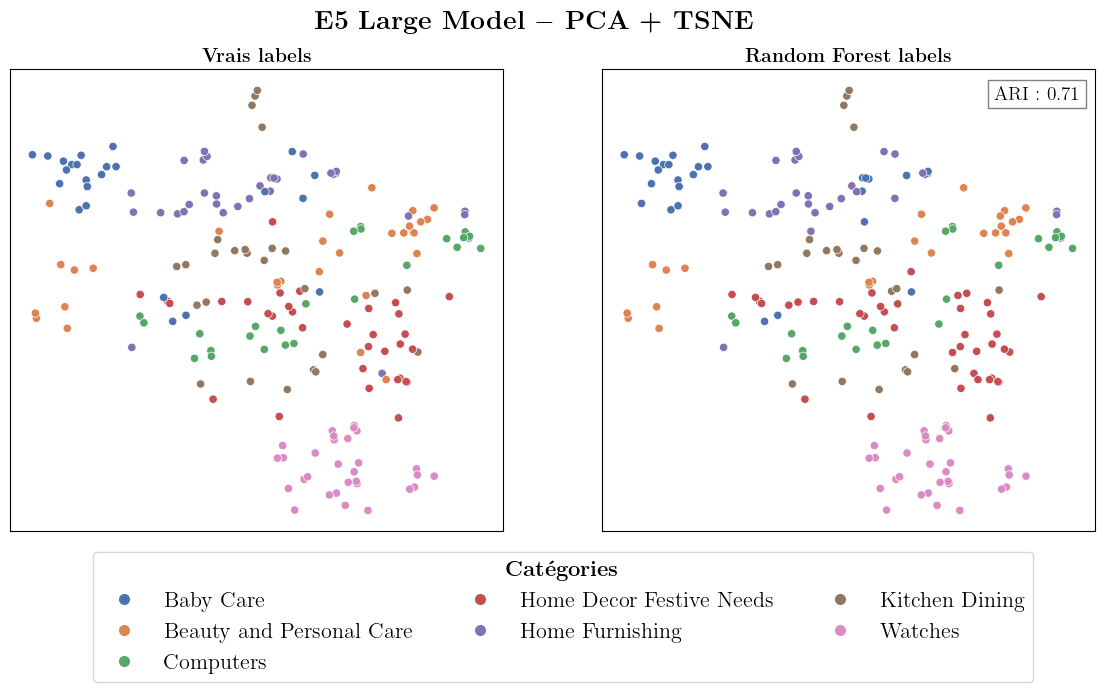

In [74]:
# quelques plots
    
fig, axes = plt.subplots(1,2, figsize = (14,6), gridspec_kw={'width_ratios':[1,1]})
sns.scatterplot(x = X_test_e5_large[:,0], y = X_test_e5_large[:,1], palette = palette_deep_mapping, legend = False, hue = y_test, ax = axes[0])
sns.scatterplot(x = X_test_e5_large[:,0], y = X_test_e5_large[:,1], palette = palette_deep_mapping, legend = False, hue = e5_large_rfc_labels, ax = axes[1])
axes[0].set_title("\\textbf{{Vrais labels}}", size = 14)
axes[1].set_title("\\textbf{{Random Forest labels}}", size = 14)
    
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].set_xticks([])
axes[0].set_yticks([])
        
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_xticks([])
axes[1].set_yticks([])
    
axes[1].text(0.97, 0.965, f"ARI : {round(data_scores.loc[data_scores['modele'] == 'e5-large-v2', 'rfc_ari'].iloc[0], 2)}", horizontalalignment='right', verticalalignment='top', transform=axes[1].transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.5))
    
#légende
category_names = label_encoder.inverse_transform(range(len(label_encoder.classes_)))
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette_deep_mapping[i], markersize=9, label=category_names[i]) for i in range(len(category_names))]
plt.legend(handles=handles, title="\\textbf{{Catégories}}", loc='lower center', bbox_to_anchor=(-0.078, -0.35), ncol=3)
        
plt.suptitle(f"\\textbf{{E5 Large Model $-$ PCA + TSNE}}")
#plt.savefig(f"graphics/e5_large_model_clustering_rfc.pdf", bbox_inches='tight')
plt.show()